In [ ]:
# CELL 1 – Install & Import

# !pip install xgboost lightgbm PyWavelets shap imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import pywt
import shap
import warnings

from scipy import signal as scipy_signal, stats
from scipy.stats import entropy as shannon_entropy
from scipy.signal import welch

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 110

print("All libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")

All libraries imported successfully!
XGBoost version: 3.2.0


In [ ]:
# CELL 2 – Synthetic Dataset (EEG-like, 500 segments)

np.random.seed(42)
N_SAMPLES   = 500
N_POINTS    = 178
FS          = 178.0          # Hz – same as UCI Epileptic dataset
N_PATIENTS  = 10             # virtual patients

t = np.linspace(0, 1, N_POINTS)

X_raw, y_raw, patient_ids = [], [], []

for i in range(N_SAMPLES):
    patient_id = i % N_PATIENTS
    if i < 100:                          # class 1 – seizure
        sig  = (5.0 * np.sin(2 * np.pi * 8  * t) +
                3.0 * np.sin(2 * np.pi * 4  * t) +
                1.5 * np.sin(2 * np.pi * 12 * t))
        sig += np.random.normal(0, 0.4, N_POINTS)
        label = 1
    else:                                # class 0 – non-seizure
        sig  = (0.8 * np.sin(2 * np.pi * 10 * t) +
                0.5 * np.random.normal(0, 1, N_POINTS))
        label = 0
    X_raw.append(sig)
    y_raw.append(label)
    patient_ids.append(patient_id)

X_df        = pd.DataFrame(X_raw)
y_binary    = np.array(y_raw)
patient_ids = np.array(patient_ids)

bands = {
    'Delta': (0.5,  4),
    'Theta': (4,    8),
    'Alpha': (8,   13),
    'Beta' : (13,  30),
}

print(f"Dataset ready – {N_SAMPLES} segments | "
      f"{sum(y_binary)} seizure | {N_SAMPLES-sum(y_binary)} non-seizure")
print(f"   {N_PATIENTS} virtual patients | FS = {FS} Hz")

Dataset ready – 500 segments | 100 seizure | 400 non-seizure
   10 virtual patients | FS = 178.0 Hz


In [ ]:
# CELL 3 – Bandpass Filtering

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq  = 0.5 * fs
    b, a = scipy_signal.butter(order,
                               [lowcut / nyq, highcut / nyq],
                               btype='band')
    return b, a

def apply_bandpass(data, lowcut, highcut, fs):
    b, a = butter_bandpass(lowcut, highcut, fs)
    return scipy_signal.filtfilt(b, a, data)

print("Bandpass filter functions defined")

Bandpass filter functions defined


In [ ]:
# CELL 4 – Multi-Domain Feature Extraction

# 4a. Statistical features (kept from original)
def stat_features(sig):
    return {
        'mean'          : np.mean(sig),
        'std'           : np.std(sig),
        'variance'      : np.var(sig),
        'skewness'      : stats.skew(sig),
        'kurtosis'      : stats.kurtosis(sig),
        'rms'           : np.sqrt(np.mean(sig ** 2)),
        'peak_to_peak'  : np.ptp(sig),
    }

# 4b. Wavelet features (kept from original)
def wavelet_features(sig, wavelet='db4', level=3):
    level  = min(level, int(np.log2(len(sig))) - 1)
    coeffs = pywt.wavedec(sig, wavelet, level=max(1, level))
    energies = [np.sum(c ** 2) for c in coeffs]
    total    = sum(energies) or 1.0
    ratios   = [e / total for e in energies]
    feats = {f'wt_energy_L{i}': e for i, e in enumerate(energies)}
    feats['wt_total_energy'] = total
    feats['wt_entropy']      = float(shannon_entropy(ratios))
    return feats

# 4c. Hjorth Parameters
def hjorth_features(sig):
    """
    Activity   = variance of the signal
    Mobility   = sqrt(var(1st deriv) / var(signal))
    Complexity = mobility(1st deriv) / mobility(signal)
    """
    d1   = np.diff(sig)
    d2   = np.diff(d1)
    var0 = np.var(sig)  or 1e-10
    var1 = np.var(d1)   or 1e-10
    var2 = np.var(d2)   or 1e-10
    activity   = var0
    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / mobility if mobility > 0 else 0.0
    return {
        'hjorth_activity'   : activity,
        'hjorth_mobility'   : mobility,
        'hjorth_complexity' : complexity,
    }

# 4d. Higuchi Fractal Dimension
def higuchi_fd(sig, kmax=6):
    """
    Higuchi (1988) – measures self-similarity / chaos level.
    Higher FD  ->  more chaotic (often non-ictal).
    Lower FD   ->  more regular / periodic (often ictal).
    """
    N    = len(sig)
    L    = []
    x    = np.asarray(sig, dtype=float)
    for k in range(1, kmax + 1):
        Lk = []
        for m in range(1, k + 1):
            idxs   = np.arange(m - 1, N, k)
            x_m    = x[idxs]
            if len(x_m) < 2:
                continue
            Lmk = (np.sum(np.abs(np.diff(x_m))) *
                   (N - 1) / (k * (len(x_m) - 1)))
            Lk.append(Lmk)
        if Lk:
            L.append(np.mean(Lk))
    if len(L) < 2:
        return {'higuchi_fd': 1.0}
    ln_k = np.log(np.arange(1, len(L) + 1))
    ln_L = np.log(np.array(L) + 1e-10)
    fd   = np.polyfit(ln_k, ln_L, 1)[0]
    return {'higuchi_fd': float(fd)}

# 4e. Approximate Entropy (ApEn)
def approx_entropy(sig, m=2, r_factor=0.2):
    """
    ApEn measures unpredictability.
    Low ApEn -> more regular/repetitive -> consistent with seizure.
    """
    N = len(sig)
    r = r_factor * np.std(sig)
    if r == 0:
        return {'approx_entropy': 0.0}

    def phi(template_len):
        templates = np.array([sig[i:i + template_len]
                               for i in range(N - template_len + 1)])
        count = np.sum(
            np.max(np.abs(templates[:, None] - templates[None, :]), axis=2) <= r,
            axis=1
        )
        return np.sum(np.log(count / (N - template_len + 1))) / (N - template_len + 1)

    apen = phi(m) - phi(m + 1)
    return {'approx_entropy': float(apen)}

# 4f. Spectral Entropy
def spectral_entropy_feature(sig, fs):
    """
    Normalised spectral entropy from Welch PSD.
    High -> broad-band / complex.  Low -> narrow-band / rhythmic (ictal).
    """
    freqs, psd = welch(sig, fs=fs, nperseg=min(64, len(sig) // 2))
    psd_norm   = psd / (psd.sum() + 1e-10)
    sp_ent     = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))
    sp_ent_n   = sp_ent / np.log2(len(psd_norm))   # normalised 0-1
    return {'spectral_entropy': float(sp_ent_n)}

# 4g. Master extraction loop
def extract_all_features(eeg, bands_dict, fs):
    feats = {}

    # Global (whole-signal) novel features
    feats.update({f'global_{k}': v
                  for k, v in hjorth_features(eeg).items()})
    feats.update({f'global_{k}': v
                  for k, v in higuchi_fd(eeg).items()})
    feats.update({f'global_{k}': v
                  for k, v in approx_entropy(eeg).items()})
    feats.update({f'global_{k}': v
                  for k, v in spectral_entropy_feature(eeg, fs).items()})

    # Per-band features
    for band, (lo, hi) in bands_dict.items():
        if hi >= fs / 2:
            continue
        try:
            filt = apply_bandpass(eeg, lo, hi, fs)
        except Exception:
            continue

        for k, v in stat_features(filt).items():
            feats[f'{band}_{k}'] = v
        for k, v in wavelet_features(filt).items():
            feats[f'{band}_{k}'] = v
        for k, v in hjorth_features(filt).items():
            feats[f'{band}_{k}'] = v
        for k, v in approx_entropy(filt).items():
            feats[f'{band}_{k}'] = v
        for k, v in spectral_entropy_feature(filt, fs).items():
            feats[f'{band}_{k}'] = v

    return feats

print("Feature extraction functions defined")
print("   Domains: Statistical | Wavelet | Hjorth | "
      "Higuchi-FD | ApEn | Spectral-Entropy")

Feature extraction functions defined
   Domains: Statistical | Wavelet | Hjorth | Higuchi-FD | ApEn | Spectral-Entropy


In [ ]:
# CELL 4 – Multi-Domain Feature Extraction

# 4a. Statistical features (kept from original)
def stat_features(sig):
    return {
        'mean'          : np.mean(sig),
        'std'           : np.std(sig),
        'variance'      : np.var(sig),
        'skewness'      : stats.skew(sig),
        'kurtosis'      : stats.kurtosis(sig),
        'rms'           : np.sqrt(np.mean(sig ** 2)),
        'peak_to_peak'  : np.ptp(sig),
    }

# 4b. Wavelet features (kept from original)
def wavelet_features(sig, wavelet='db4', level=3):
    level  = min(level, int(np.log2(len(sig))) - 1)
    coeffs = pywt.wavedec(sig, wavelet, level=max(1, level))
    energies = [np.sum(c ** 2) for c in coeffs]
    total    = sum(energies) or 1.0
    ratios   = [e / total for e in energies]
    feats = {f'wt_energy_L{i}': e for i, e in enumerate(energies)}
    feats['wt_total_energy'] = total
    feats['wt_entropy']      = float(shannon_entropy(ratios))
    return feats

# 4c. Hjorth Parameters
def hjorth_features(sig):
    """
    Activity   = variance of the signal
    Mobility   = sqrt(var(1st deriv) / var(signal))
    Complexity = mobility(1st deriv) / mobility(signal)
    """
    d1   = np.diff(sig)
    d2   = np.diff(d1)
    var0 = np.var(sig)  or 1e-10
    var1 = np.var(d1)   or 1e-10
    var2 = np.var(d2)   or 1e-10
    activity   = var0
    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / mobility if mobility > 0 else 0.0
    return {
        'hjorth_activity'   : activity,
        'hjorth_mobility'   : mobility,
        'hjorth_complexity' : complexity,
    }

# 4d. Higuchi Fractal Dimension
def higuchi_fd(sig, kmax=6):
    """
    Higuchi (1988) – measures self-similarity / chaos level.
    Higher FD  ->  more chaotic (often non-ictal).
    Lower FD   ->  more regular / periodic (often ictal).
    """
    N    = len(sig)
    L    = []
    x    = np.asarray(sig, dtype=float)
    for k in range(1, kmax + 1):
        Lk = []
        for m in range(1, k + 1):
            idxs   = np.arange(m - 1, N, k)
            x_m    = x[idxs]
            if len(x_m) < 2:
                continue
            Lmk = (np.sum(np.abs(np.diff(x_m))) *
                   (N - 1) / (k * (len(x_m) - 1)))
            Lk.append(Lmk)
        if Lk:
            L.append(np.mean(Lk))
    if len(L) < 2:
        return {'higuchi_fd': 1.0}
    ln_k = np.log(np.arange(1, len(L) + 1))
    ln_L = np.log(np.array(L) + 1e-10)
    fd   = np.polyfit(ln_k, ln_L, 1)[0]
    return {'higuchi_fd': float(fd)}

# 4e. Approximate Entropy (ApEn)
def approx_entropy(sig, m=2, r_factor=0.2):
    """
    ApEn measures unpredictability.
    Low ApEn -> more regular/repetitive -> consistent with seizure.
    """
    N = len(sig)
    r = r_factor * np.std(sig)
    if r == 0:
        return {'approx_entropy': 0.0}

    def phi(template_len):
        templates = np.array([sig[i:i + template_len]
                               for i in range(N - template_len + 1)])
        count = np.sum(
            np.max(np.abs(templates[:, None] - templates[None, :]), axis=2) <= r,
            axis=1
        )
        return np.sum(np.log(count / (N - template_len + 1))) / (N - template_len + 1)

    apen = phi(m) - phi(m + 1)
    return {'approx_entropy': float(apen)}

# 4f. Spectral Entropy
def spectral_entropy_feature(sig, fs):
    """
    Normalised spectral entropy from Welch PSD.
    High -> broad-band / complex.  Low -> narrow-band / rhythmic (ictal).
    """
    freqs, psd = welch(sig, fs=fs, nperseg=min(64, len(sig) // 2))
    psd_norm   = psd / (psd.sum() + 1e-10)
    sp_ent     = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))
    sp_ent_n   = sp_ent / np.log2(len(psd_norm))   # normalised 0-1
    return {'spectral_entropy': float(sp_ent_n)}

# 4g. Master extraction loop
def extract_all_features(eeg, bands_dict, fs):
    feats = {}

    # Global (whole-signal) novel features
    feats.update({f'global_{k}': v
                  for k, v in hjorth_features(eeg).items()})
    feats.update({f'global_{k}': v
                  for k, v in higuchi_fd(eeg).items()})
    feats.update({f'global_{k}': v
                  for k, v in approx_entropy(eeg).items()})
    feats.update({f'global_{k}': v
                  for k, v in spectral_entropy_feature(eeg, fs).items()})

    # Per-band features
    for band, (lo, hi) in bands_dict.items():
        if hi >= fs / 2:
            continue
        try:
            filt = apply_bandpass(eeg, lo, hi, fs)
        except Exception:
            continue

        for k, v in stat_features(filt).items():
            feats[f'{band}_{k}'] = v
        for k, v in wavelet_features(filt).items():
            feats[f'{band}_{k}'] = v
        for k, v in hjorth_features(filt).items():
            feats[f'{band}_{k}'] = v
        for k, v in approx_entropy(filt).items():
            feats[f'{band}_{k}'] = v
        for k, v in spectral_entropy_feature(filt, fs).items():
            feats[f'{band}_{k}'] = v

    return feats

print("Feature extraction functions defined")
print("   Domains: Statistical | Wavelet | Hjorth | "
      "Higuchi-FD | ApEn | Spectral-Entropy")

Feature extraction functions defined
   Domains: Statistical | Wavelet | Hjorth | Higuchi-FD | ApEn | Spectral-Entropy


In [ ]:
# CELL 5 – Extract Features from All 500 Segments

print("Extracting multi-domain features …")
rows = []
for i in range(len(X_df)):
    if i % 100 == 0:
        print(f"  [{i:>3}/500]")
    rows.append(extract_all_features(X_df.iloc[i].values, bands, FS))

feat_df = pd.DataFrame(rows)
feat_df.replace([np.inf, -np.inf], np.nan, inplace=True)
feat_df.fillna(feat_df.mean(), inplace=True)
feat_df['target']     = y_binary
feat_df['patient_id'] = patient_ids

print(f"\nFeature matrix: {feat_df.shape[0]} samples x "
      f"{feat_df.shape[1]-2} features")

Extracting multi-domain features …
  [  0/500]
  [100/500]
  [200/500]
  [300/500]
  [400/500]

Feature matrix: 500 samples x 78 features


In [ ]:
# CELL 6 – Automatic Feature Selection

X_all = feat_df.drop(columns=['target', 'patient_id'])
y_all = feat_df['target']

# Step 1 – univariate filter (keep top-60)
selector_uni = SelectKBest(f_classif, k=min(60, X_all.shape[1]))
X_uni        = selector_uni.fit_transform(X_all, y_all)
selected_uni = X_all.columns[selector_uni.get_support()].tolist()

# Step 2 – RFE with a lightweight RF to pick top-40
rfe_base  = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rfe       = RFE(rfe_base, n_features_to_select=min(40, len(selected_uni)), step=5)
X_selected_arr = rfe.fit_transform(X_all[selected_uni], y_all)
selected_final = [selected_uni[i] for i, s in enumerate(rfe.support_) if s]

X_sel = pd.DataFrame(X_selected_arr, columns=selected_final)

print(f"Feature selection complete")
print(f"   Original features : {X_all.shape[1]}")
print(f"   After univariate  : {len(selected_uni)}")
print(f"   After RFE         : {len(selected_final)}")

Feature selection complete
   Original features : 78
   After univariate  : 60
   After RFE         : 40


In [ ]:
# CELL 7 – Train / Test Split & Ensemble Model

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y_all, test_size=0.2, stratify=y_all, random_state=42)

scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_test_sc     = scaler.transform(X_test)

# Base learners
xgb_clf = xgb.XGBClassifier(
    n_estimators   = 200,
    max_depth       = 4,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    use_label_encoder=False,
    eval_metric     = 'logloss',
    random_state    = 42,
    n_jobs          = -1
)

rf_clf = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 6,
    min_samples_split = 10,
    random_state = 42,
    n_jobs       = -1
)

# Soft-voting ensemble
ensemble = VotingClassifier(
    estimators=[('xgb', xgb_clf), ('rf', rf_clf)],
    voting='soft',
    n_jobs=-1
)

ensemble.fit(X_train_sc, y_train)

y_pred      = ensemble.predict(X_test_sc)
y_proba     = ensemble.predict_proba(X_test_sc)[:, 1]
roc_auc     = roc_auc_score(y_test, y_proba)
accuracy    = (y_pred == y_test).mean()

print("\n" + "=" * 60)
print("  ENSEMBLE MODEL - CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred,
                             target_names=['Non-Seizure', 'Seizure']))
print(f"  ROC-AUC  : {roc_auc:.4f}")
print(f"  Accuracy : {accuracy:.4f}")

# 5-fold cross-validation
cv_scores = cross_val_score(ensemble, X_sel, y_all,
                             cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='roc_auc')
print(f"\n  5-Fold CV AUC : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

In [ ]:
# CELL 8 – Seizure Risk Score (0-100)

def seizure_risk_score(proba):
    """Map raw probability to a 0-100 clinical risk scale."""
    return np.round(proba * 100, 1)

risk_scores_test = seizure_risk_score(y_proba)

# Risk bands
def risk_label(score):
    if score < 30:
        return 'Low'
    elif score < 65:
        return 'Moderate'
    else:
        return 'High'

risk_labels = [risk_label(s) for s in risk_scores_test]

# Compute risk for ALL segments (for patient dashboard)
y_proba_all   = ensemble.predict_proba(scaler.transform(X_sel))[:, 1]
risk_all       = seizure_risk_score(y_proba_all)
feat_df['risk_score']  = risk_all
feat_df['risk_label']  = [risk_label(s) for s in risk_all]
feat_df['pred_label']  = ensemble.predict(scaler.transform(X_sel))

print("Seizure Risk Scores computed for all 500 segments")
print(f"   High risk  : {sum(r == 'High'     for r in feat_df['risk_label'])} segments")
print(f"   Moderate   : {sum(r == 'Moderate' for r in feat_df['risk_label'])} segments")
print(f"   Low risk   : {sum(r == 'Low'      for r in feat_df['risk_label'])} segments")

Seizure Risk Scores computed for all 500 segments
   High risk  : 100 segments
   Moderate   : 0 segments
   Low risk   : 400 segments


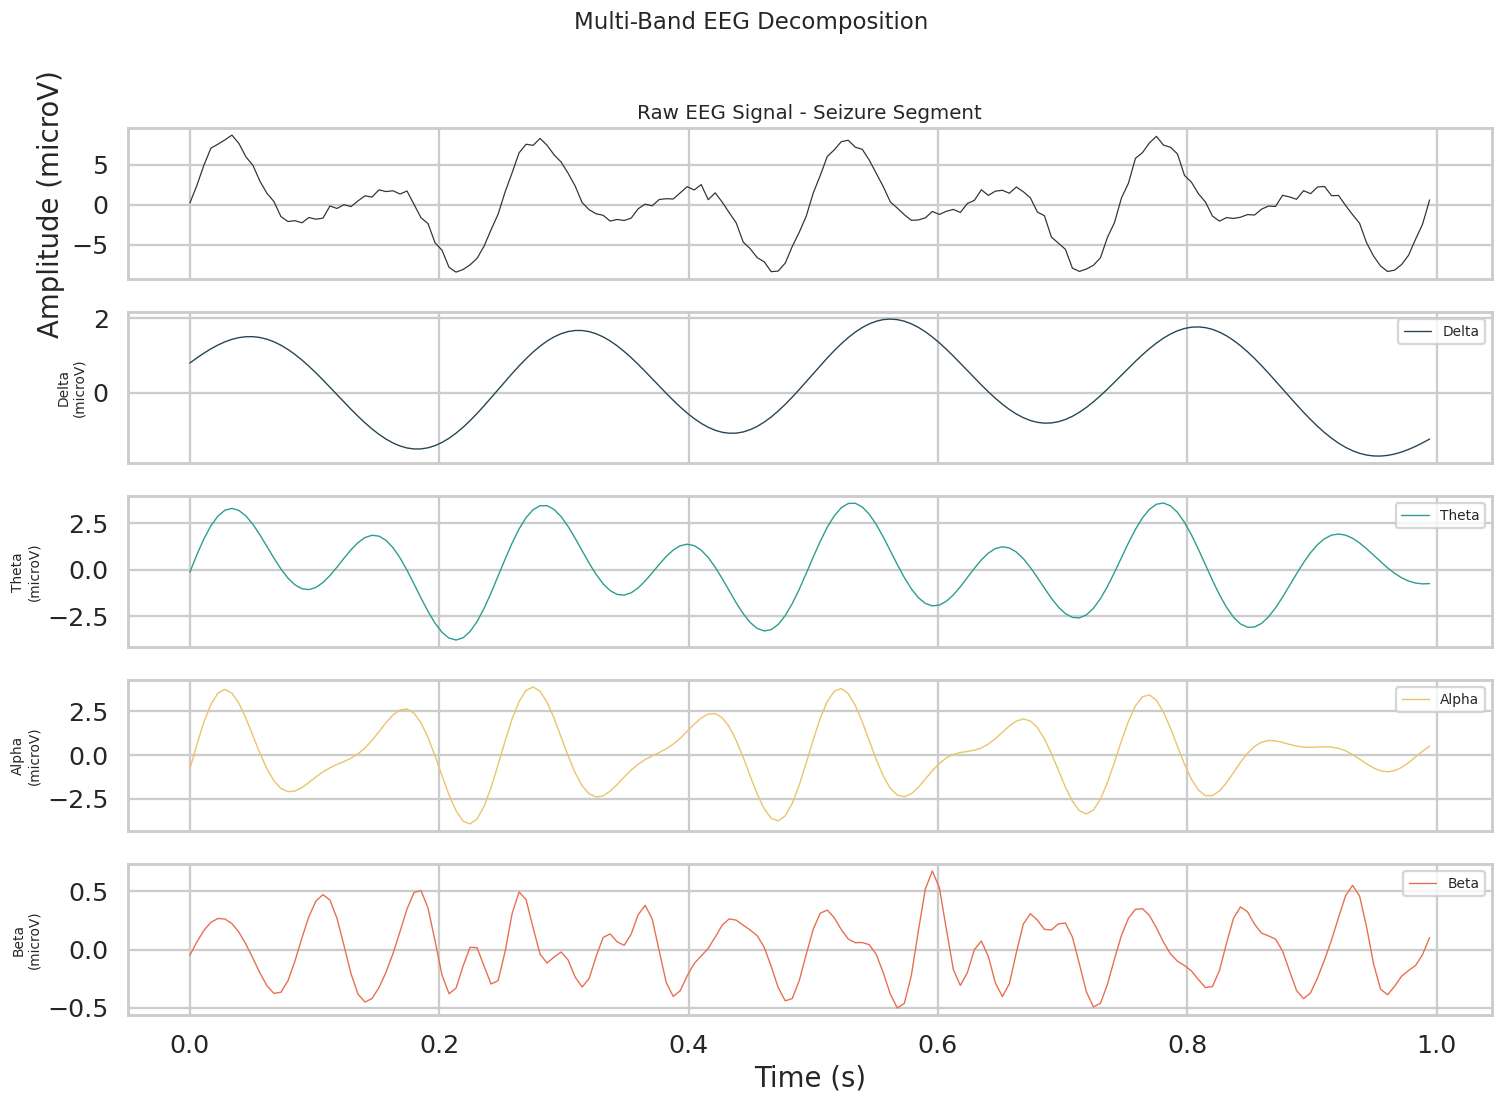

Fig 1 - EEG decomposition saved


In [ ]:
# CELL 9 – Visualisation Suite

COLORS = {
    'seizure'    : '#E63946',
    'non_seizure': '#457B9D',
    'high'       : '#E63946',
    'moderate'   : '#F4A261',
    'low'        : '#2A9D8F',
}

# Fig 1: EEG decomposition
sample   = X_df.iloc[0].values
time_ax  = np.arange(N_POINTS) / FS
fig, axes = plt.subplots(len(bands) + 1, 1, figsize=(14, 10), sharex=True)

axes[0].plot(time_ax, sample, color='#333333', lw=0.8)
axes[0].set_title('Raw EEG Signal - Seizure Segment', fontsize=13)
axes[0].set_ylabel('Amplitude (microV)')

pal = ['#264653', '#2A9D8F', '#E9C46A', '#E76F51']
for idx, (bname, (lo, hi)) in enumerate(bands.items(), 1):
    filt = apply_bandpass(sample, lo, hi, FS)
    axes[idx].plot(time_ax, filt, color=pal[idx-1], lw=0.9, label=bname)
    axes[idx].set_ylabel(f'{bname}\n(microV)', fontsize=9)
    axes[idx].legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Multi-Band EEG Decomposition', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig1_eeg_decomposition.png', bbox_inches='tight')
plt.show()
print("Fig 1 - EEG decomposition saved")

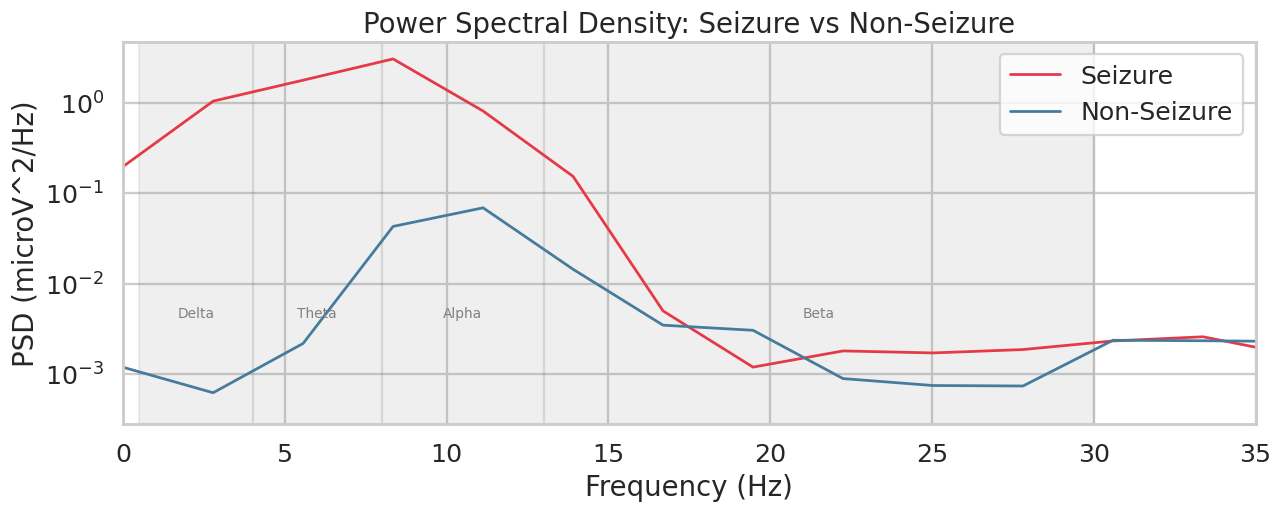

Fig 2 - PSD saved


In [ ]:
# CELL 9b – PSD Comparison

fig, ax = plt.subplots(figsize=(12, 5))
for cls, color, label in [(1, COLORS['seizure'],     'Seizure'),
                           (0, COLORS['non_seizure'], 'Non-Seizure')]:
    idx  = np.where(y_binary == cls)[0][0]
    f, p = welch(X_df.iloc[idx].values, FS,
                 nperseg=min(64, N_POINTS // 2))
    ax.semilogy(f, p, color=color, lw=1.8, label=label)

for bname, (lo, hi) in bands.items():
    ax.axvspan(lo, hi, alpha=0.12, color='gray')
    ax.text((lo + hi) / 2, ax.get_ylim()[0] * 15, bname,
            ha='center', fontsize=9, color='gray')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (microV^2/Hz)')
ax.set_title('Power Spectral Density: Seizure vs Non-Seizure')
ax.set_xlim([0, 35])
ax.legend()
plt.tight_layout()
plt.savefig('fig2_psd.png', bbox_inches='tight')
plt.show()
print("Fig 2 - PSD saved")

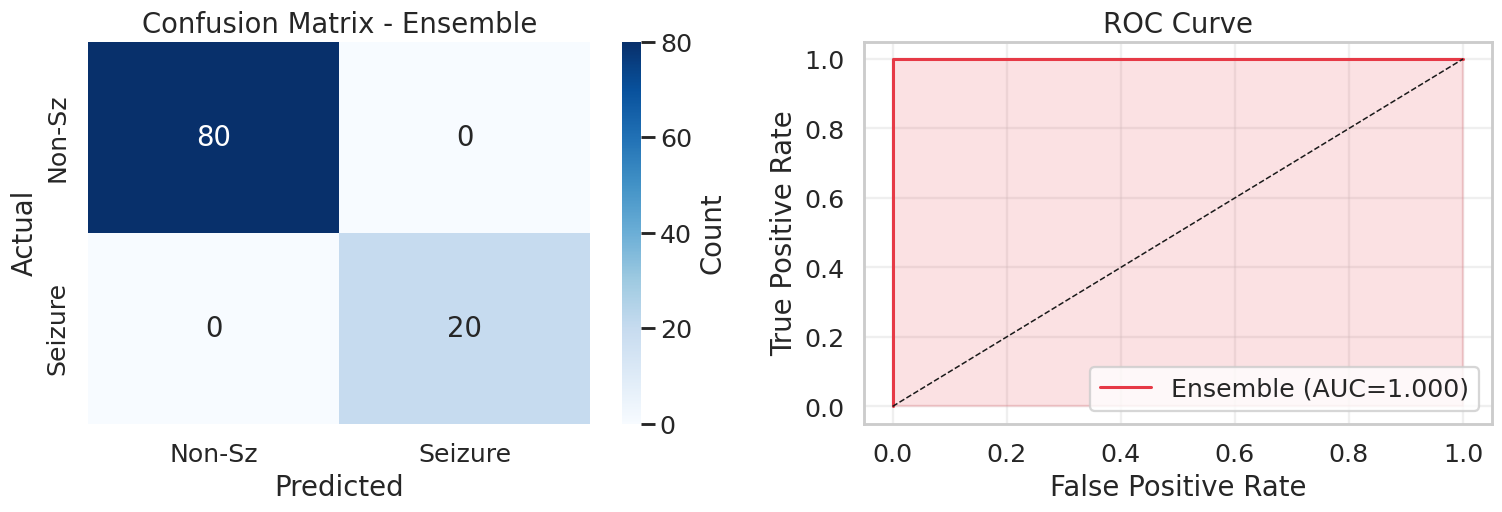

Fig 3 - Confusion matrix & ROC saved


In [ ]:
# CELL 9c – Confusion Matrix + ROC

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Sz', 'Seizure'],
            yticklabels=['Non-Sz', 'Seizure'], ax=ax1,
            cbar_kws={'label': 'Count'})
ax1.set_title('Confusion Matrix - Ensemble')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax2.plot(fpr, tpr, color=COLORS['seizure'], lw=2,
         label=f'Ensemble (AUC={roc_auc:.3f})')
ax2.fill_between(fpr, tpr, alpha=0.15, color=COLORS['seizure'])
ax2.plot([0, 1], [0, 1], 'k--', lw=1)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_cm_roc.png', bbox_inches='tight')
plt.show()
print("Fig 3 - Confusion matrix & ROC saved")

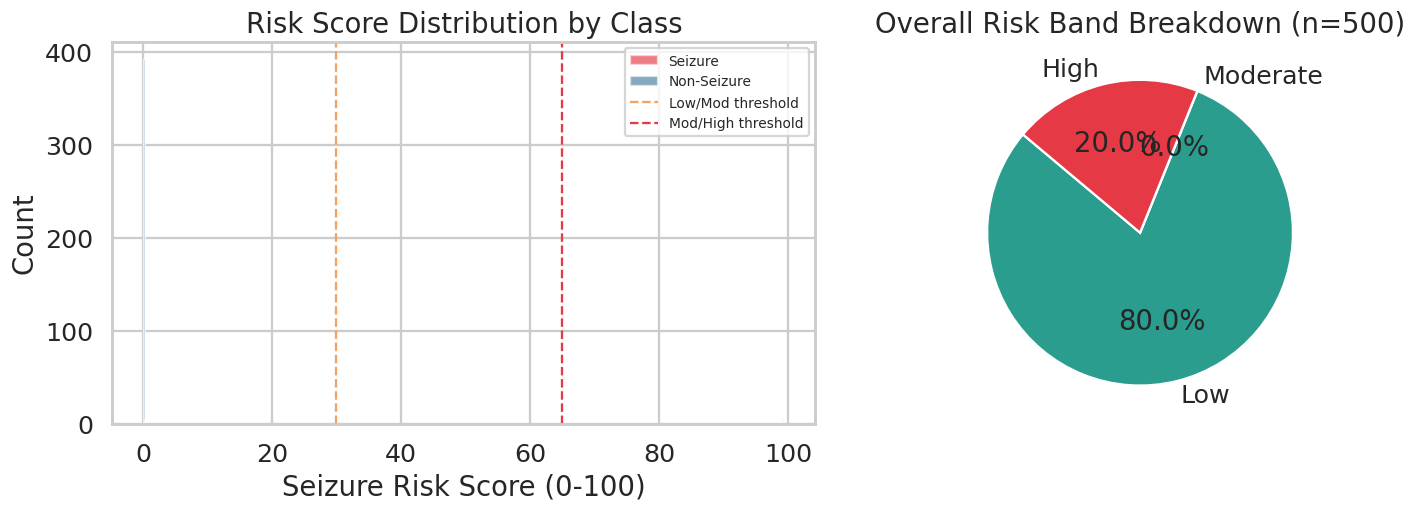

Fig 4 - Risk score distribution saved


In [ ]:
# CELL 9d – Seizure Risk Score Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for cls, color, label in [(1, COLORS['seizure'],     'Seizure'),
                           (0, COLORS['non_seizure'], 'Non-Seizure')]:
    mask = y_all.values == cls
    axes[0].hist(risk_all[mask], bins=20, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[0].axvline(30, color='#F4A261', ls='--', lw=1.5, label='Low/Mod threshold')
axes[0].axvline(65, color='#E63946', ls='--', lw=1.5, label='Mod/High threshold')
axes[0].set_xlabel('Seizure Risk Score (0-100)')
axes[0].set_ylabel('Count')
axes[0].set_title('Risk Score Distribution by Class')
axes[0].legend(fontsize=9)

# Pie chart of risk bands
counts = feat_df['risk_label'].value_counts()
order  = ['Low', 'Moderate', 'High']
vals   = [counts.get(k, 0) for k in order]
clrs   = [COLORS['low'], COLORS['moderate'], COLORS['high']]
axes[1].pie(vals, labels=order, colors=clrs, autopct='%1.1f%%',
            startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Overall Risk Band Breakdown (n=500)')
plt.tight_layout()
plt.savefig('fig4_risk_score.png', bbox_inches='tight')
plt.show()
print("Fig 4 - Risk score distribution saved")

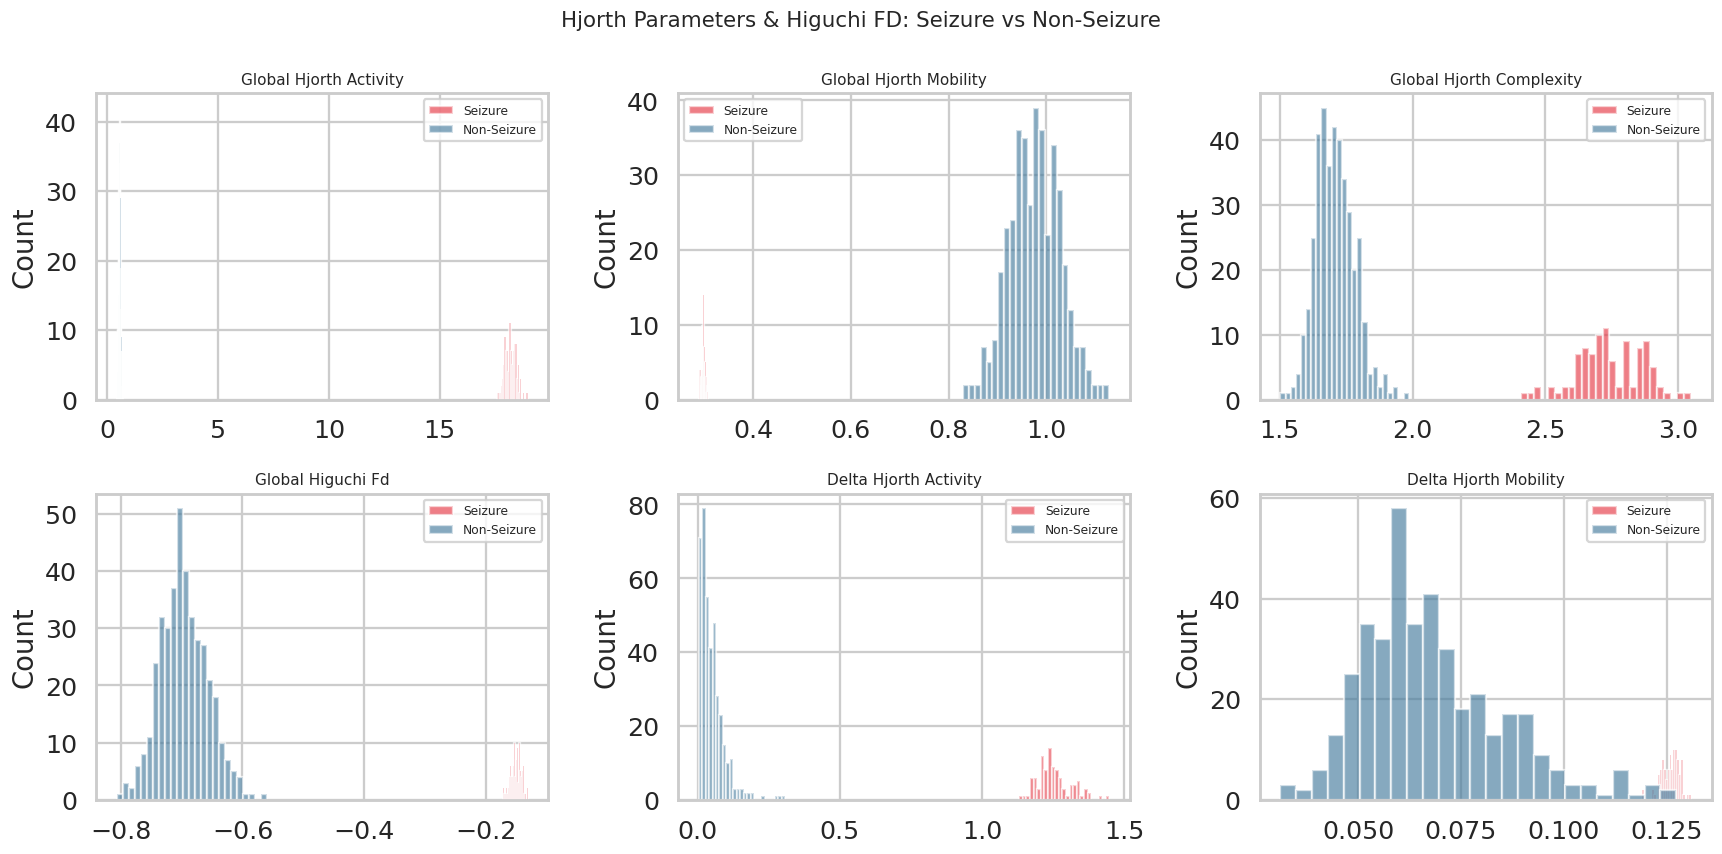

Fig 5 - Hjorth & Fractal feature distributions saved


In [ ]:
# CELL 9e – Hjorth & Fractal Feature Comparison

hjorth_cols = [c for c in feat_df.columns if 'hjorth' in c or 'higuchi' in c]
fig, axes   = plt.subplots(2, 3, figsize=(16, 8))
axes        = axes.flatten()

for i, col in enumerate(hjorth_cols[:6]):
    for cls, color, label in [(1, COLORS['seizure'],     'Seizure'),
                               (0, COLORS['non_seizure'], 'Non-Seizure')]:
        mask = feat_df['target'] == cls
        axes[i].hist(feat_df.loc[mask, col], bins=25, alpha=0.65,
                     color=color, label=label, edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Count')

plt.suptitle('Hjorth Parameters & Higuchi FD: Seizure vs Non-Seizure',
             fontsize=14)
plt.tight_layout()
plt.savefig('fig5_hjorth_higuchi.png', bbox_inches='tight')
plt.show()
print("Fig 5 - Hjorth & Fractal feature distributions saved")

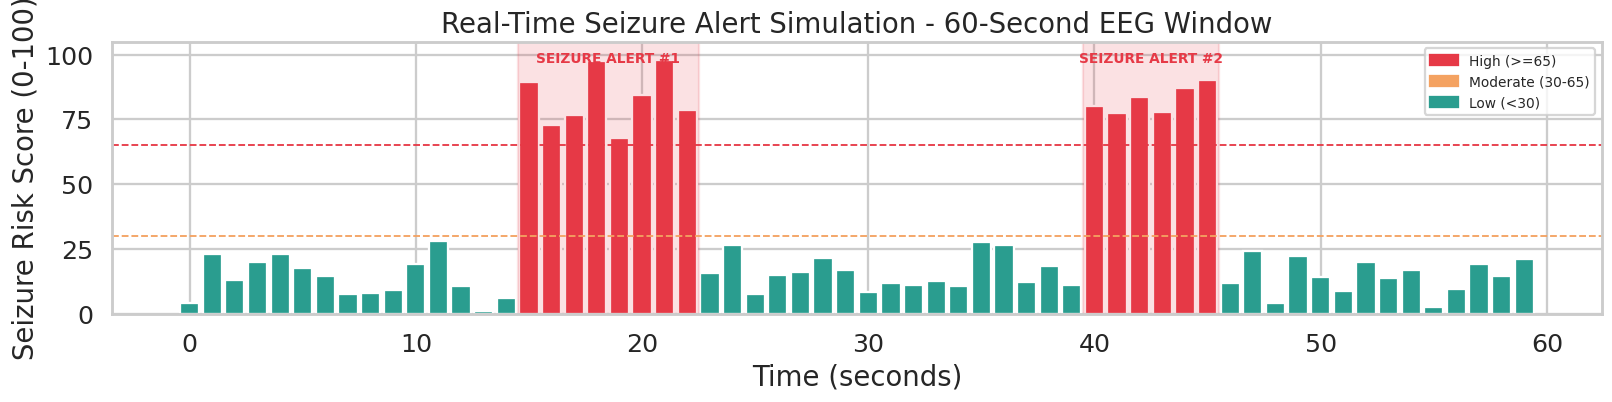

Fig 6 - Real-time alert simulation saved


In [ ]:
# CELL 9f – Real-Time Seizure Alert Simulation

np.random.seed(7)
sim_time  = np.arange(60)
sim_risk  = np.zeros(60)
# Inject seizure events at t=15-22 and t=40-45
for i in range(60):
    if 15 <= i <= 22 or 40 <= i <= 45:
        sim_risk[i] = np.random.uniform(68, 95)
    else:
        sim_risk[i] = np.random.uniform(2, 28)

sim_risk += np.random.normal(0, 3, 60)
sim_risk  = np.clip(sim_risk, 0, 100)

fig, ax = plt.subplots(figsize=(15, 4))
for i in range(len(sim_time)):
    color = (COLORS['high']     if sim_risk[i] >= 65 else
             COLORS['moderate'] if sim_risk[i] >= 30 else
             COLORS['low'])
    ax.bar(sim_time[i], sim_risk[i], color=color, width=0.85, edgecolor='white')

ax.axhline(65, color=COLORS['high'],     ls='--', lw=1.2, label='High risk threshold (65)')
ax.axhline(30, color=COLORS['moderate'], ls='--', lw=1.2, label='Mod risk threshold (30)')

# Annotate alert windows
for start, end, label in [(15, 22, 'SEIZURE ALERT #1'), (40, 45, 'SEIZURE ALERT #2')]:
    ax.axvspan(start - 0.5, end + 0.5, alpha=0.15,
               color=COLORS['high'], label=label)
    ax.text((start + end) / 2, 97, label,
            ha='center', color=COLORS['high'], fontsize=9, fontweight='bold')

high_patch = mpatches.Patch(color=COLORS['high'],     label='High (>=65)')
mod_patch  = mpatches.Patch(color=COLORS['moderate'], label='Moderate (30-65)')
low_patch  = mpatches.Patch(color=COLORS['low'],      label='Low (<30)')
ax.legend(handles=[high_patch, mod_patch, low_patch], loc='upper right', fontsize=9)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Seizure Risk Score (0-100)')
ax.set_title('Real-Time Seizure Alert Simulation - 60-Second EEG Window')
ax.set_ylim([0, 105])
plt.tight_layout()
plt.savefig('fig6_realtime_alert.png', bbox_inches='tight')
plt.show()
print("Fig 6 - Real-time alert simulation saved")

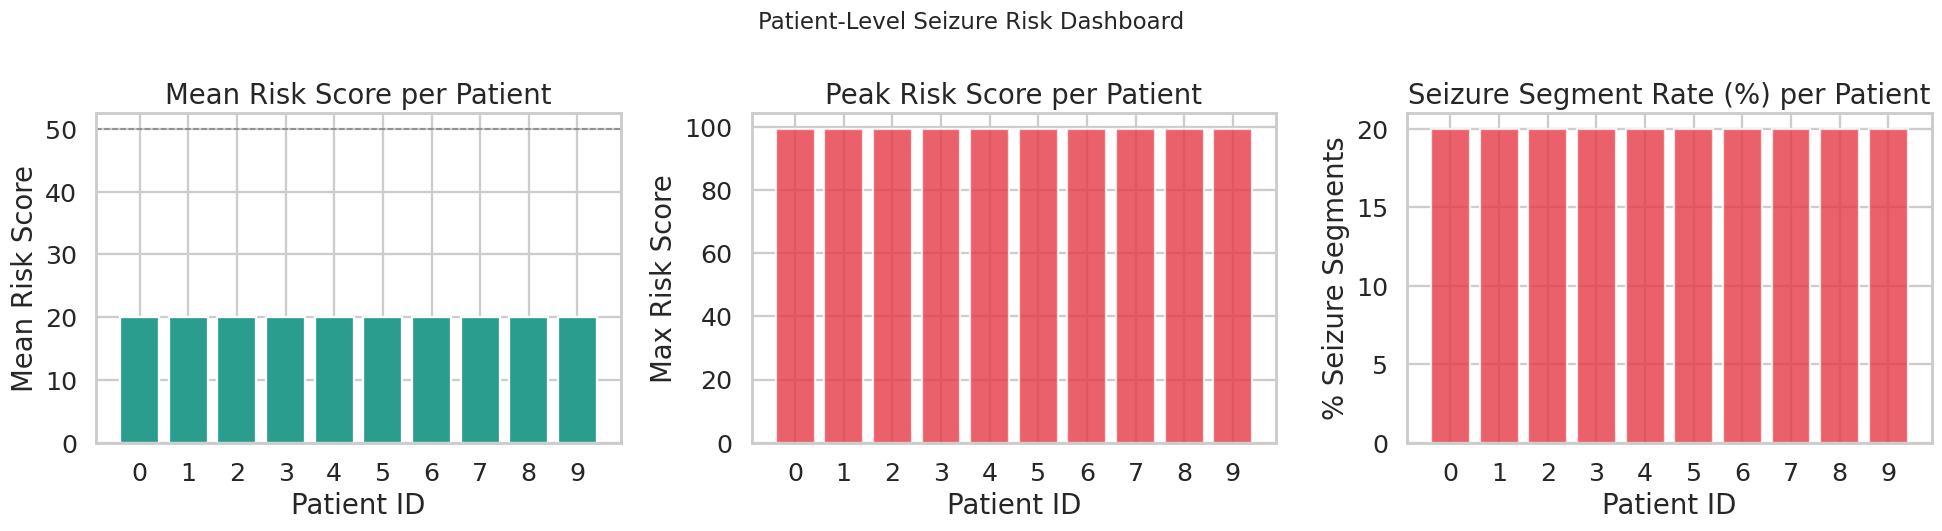

Fig 7 - Patient risk dashboard saved

Patient Summary Table:
 patient_id  total_segments  seizure_segs  mean_risk  max_risk  high_risk_segs  seizure_rate
          0              50            10     19.998      99.3              10          20.0
          1              50            10     20.020      99.3              10          20.0
          2              50            10     20.016      99.3              10          20.0
          3              50            10     20.020      99.3              10          20.0
          4              50            10     20.020      99.3              10          20.0
          5              50            10     20.010      99.3              10          20.0
          6              50            10     19.996      99.3              10          20.0
          7              50            10     20.018      99.3              10          20.0
          8              50            10     20.040      99.3              10          20.0
         

In [ ]:
# CELL 9g – Patient-Level Risk Dashboard

patient_summary = (feat_df.groupby('patient_id')
                   .agg(
                       total_segments =('target', 'count'),
                       seizure_segs   =('target', 'sum'),
                       mean_risk      =('risk_score', 'mean'),
                       max_risk       =('risk_score', 'max'),
                       high_risk_segs =(
                           'risk_label',
                           lambda x: (x == 'High').sum()
                       )
                   ).reset_index())

patient_summary['seizure_rate'] = (patient_summary['seizure_segs'] /
                                    patient_summary['total_segments'] * 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean risk per patient
colors_p = [COLORS['high'] if r >= 50 else COLORS['low']
            for r in patient_summary['mean_risk']]
axes[0].bar(patient_summary['patient_id'].astype(str),
            patient_summary['mean_risk'], color=colors_p,
            edgecolor='white')
axes[0].set_title('Mean Risk Score per Patient')
axes[0].set_xlabel('Patient ID')
axes[0].set_ylabel('Mean Risk Score')
axes[0].axhline(50, color='gray', ls='--', lw=1)

# Max risk per patient
axes[1].bar(patient_summary['patient_id'].astype(str),
            patient_summary['max_risk'], color=COLORS['high'],
            edgecolor='white', alpha=0.8)
axes[1].set_title('Peak Risk Score per Patient')
axes[1].set_xlabel('Patient ID')
axes[1].set_ylabel('Max Risk Score')

# Seizure rate
axes[2].bar(patient_summary['patient_id'].astype(str),
            patient_summary['seizure_rate'], color=COLORS['seizure'],
            edgecolor='white', alpha=0.8)
axes[2].set_title('Seizure Segment Rate (%) per Patient')
axes[2].set_xlabel('Patient ID')
axes[2].set_ylabel('% Seizure Segments')

plt.suptitle('Patient-Level Seizure Risk Dashboard', fontsize=15)
plt.tight_layout()
plt.savefig('fig7_patient_dashboard.png', bbox_inches='tight')
plt.show()
print("Fig 7 - Patient risk dashboard saved")
print("\nPatient Summary Table:")
print(patient_summary.to_string(index=False))

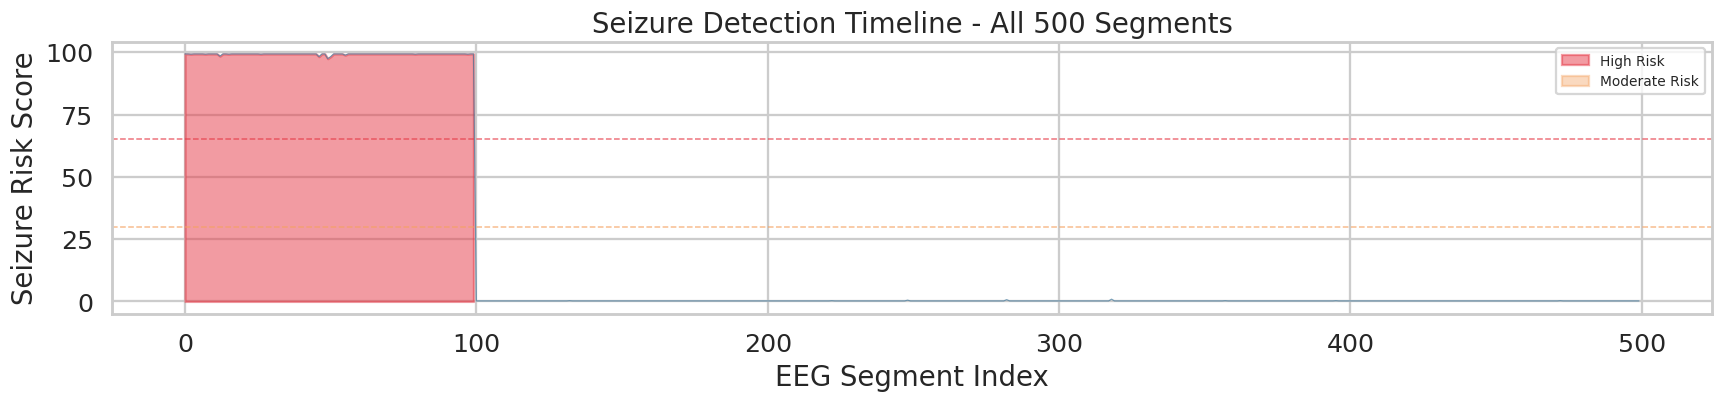

Fig 8 - Detection timeline saved


In [ ]:
# CELL 9h – Seizure Detection Timeline

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(range(len(risk_all)), risk_all, lw=0.8,
        color=COLORS['non_seizure'], alpha=0.7)
ax.fill_between(range(len(risk_all)), risk_all,
                where=(risk_all >= 65),
                color=COLORS['high'], alpha=0.5, label='High Risk')
ax.fill_between(range(len(risk_all)), risk_all,
                where=((risk_all >= 30) & (risk_all < 65)),
                color=COLORS['moderate'], alpha=0.4, label='Moderate Risk')
ax.axhline(65, color=COLORS['high'],     ls='--', lw=1, alpha=0.7)
ax.axhline(30, color=COLORS['moderate'], ls='--', lw=1, alpha=0.7)
ax.set_xlabel('EEG Segment Index')
ax.set_ylabel('Seizure Risk Score')
ax.set_title('Seizure Detection Timeline - All 500 Segments')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('fig8_detection_timeline.png', bbox_inches='tight')
plt.show()
print("Fig 8 - Detection timeline saved")

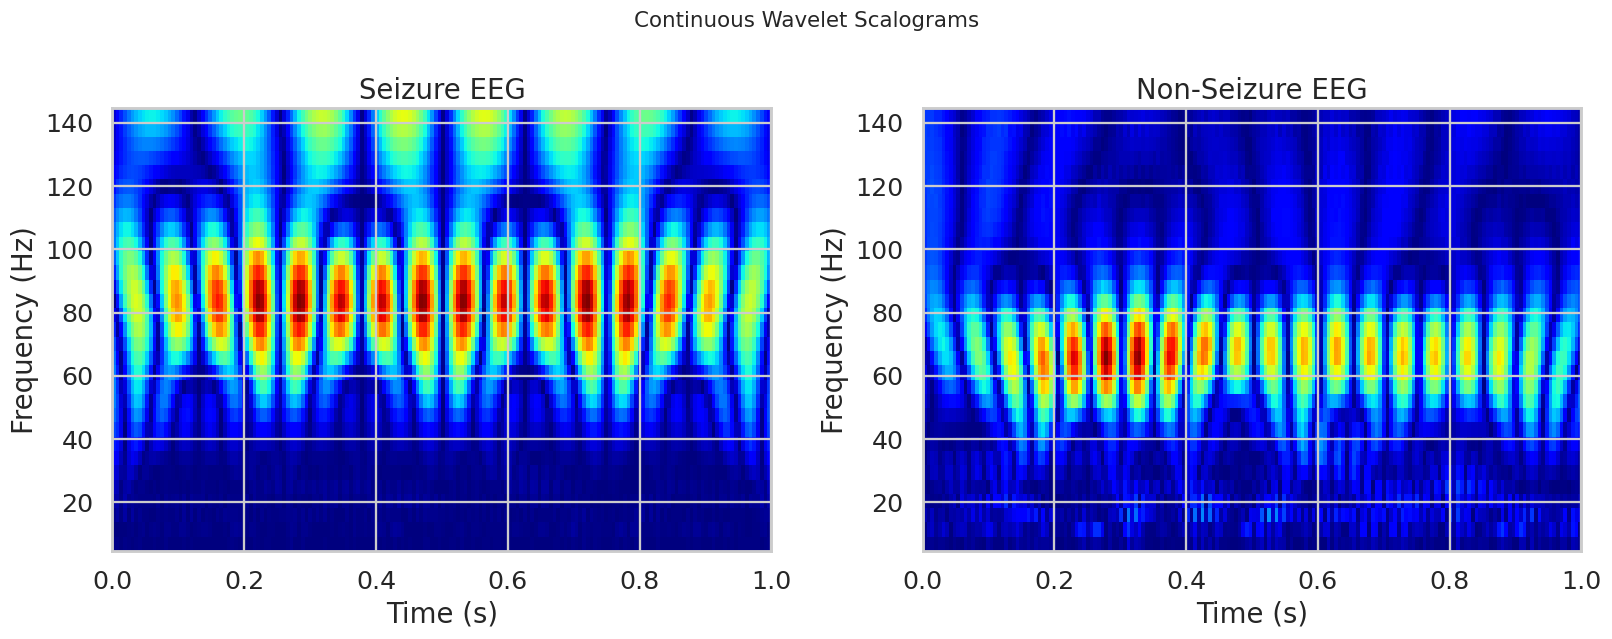

Fig 9 - Wavelet scalograms saved


In [ ]:
# CELL 9i – Wavelet Scalograms

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, idx, title in [(axes[0], np.where(y_binary == 1)[0][0], 'Seizure EEG'),
                        (axes[1], np.where(y_binary == 0)[0][0], 'Non-Seizure EEG')]:
    sig    = X_df.iloc[idx].values
    scales = np.arange(1, 32)
    coefs, freqs = pywt.cwt(sig, scales, 'morl', sampling_period=1 / FS)
    ax.imshow(np.abs(coefs), aspect='auto', origin='lower',
              extent=[0, len(sig) / FS, freqs[-1], freqs[0]],
              cmap='jet')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(title)

plt.suptitle('Continuous Wavelet Scalograms', fontsize=14)
plt.tight_layout()
plt.savefig('fig9_scalograms.png', bbox_inches='tight')
plt.show()
print("Fig 9 - Wavelet scalograms saved")

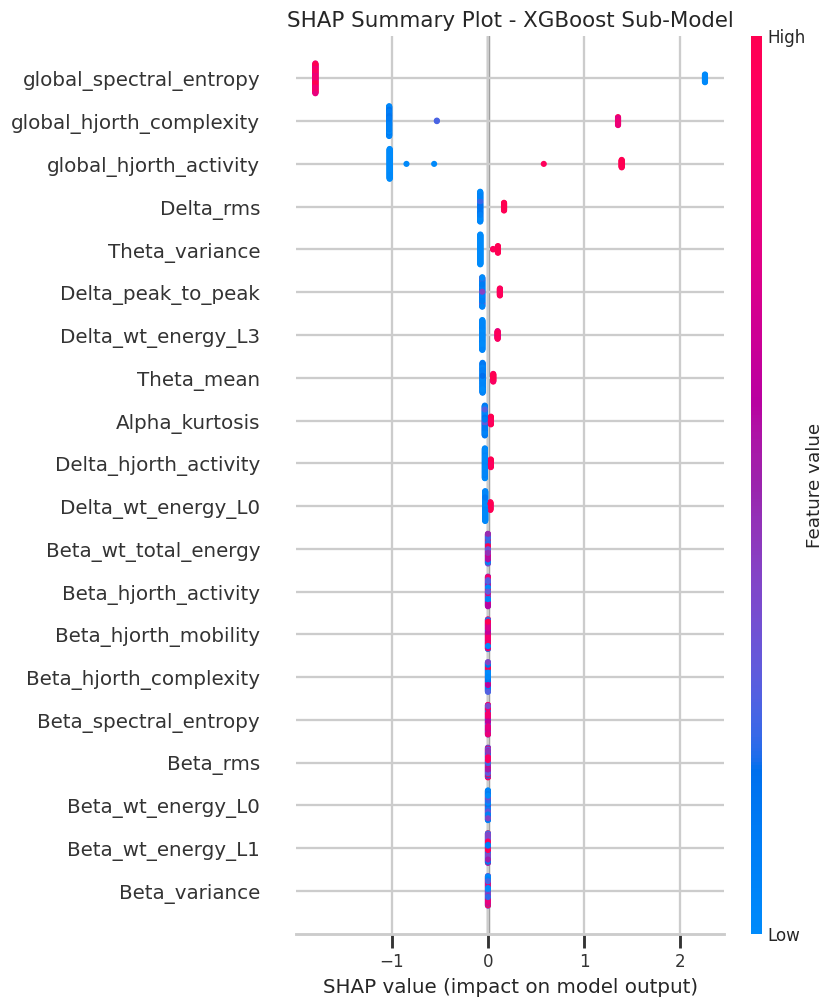

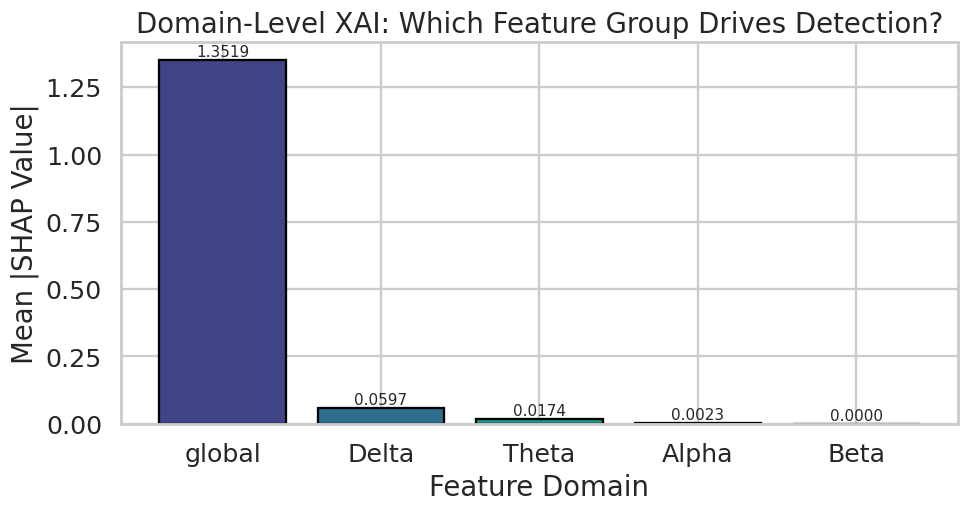

SHAP analysis complete

Most informative domain: global
Clinical note: Global non-linear metrics (ApEn, Higuchi FD) capture whole-brain chaos reduction.


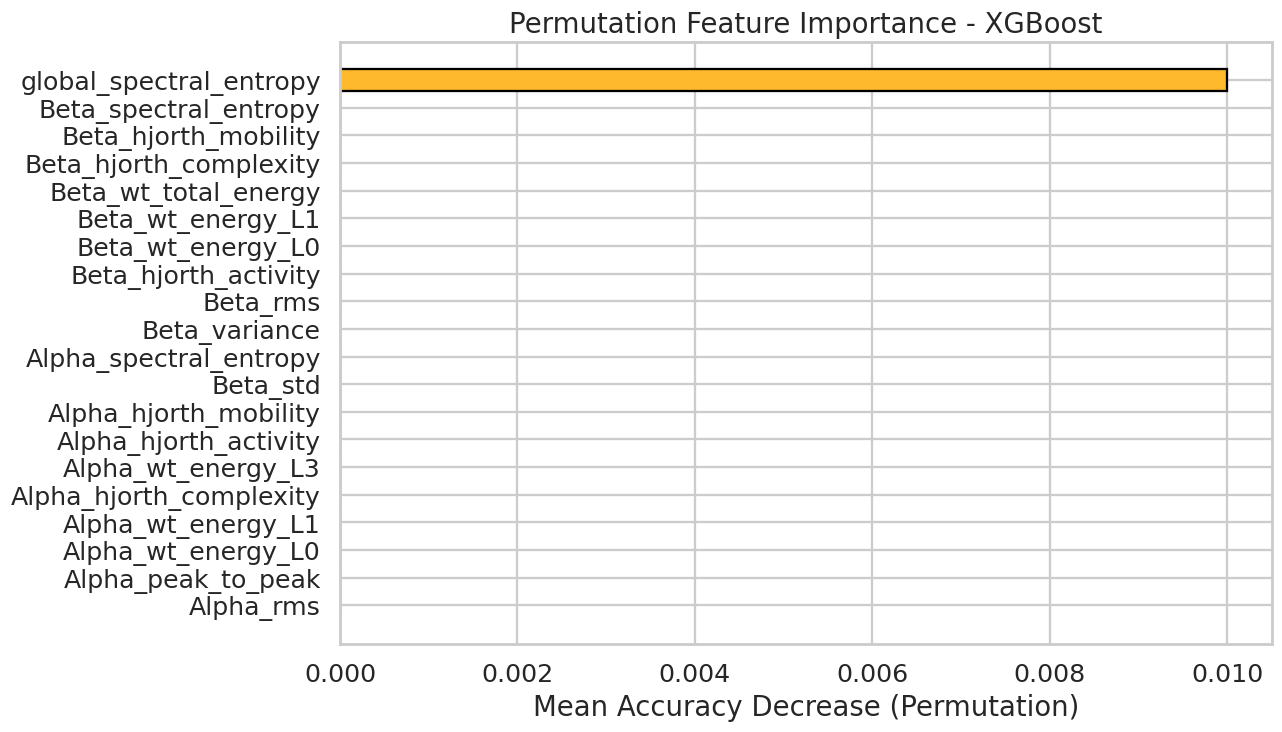

Permutation importance plot saved


In [ ]:
# CELL 10 – XAI: SHAP + Permutation Importance

# SHAP on XGBoost sub-model (TreeExplainer is fast & exact)
xgb_sub    = ensemble.estimators_[0]   # the XGBoost estimator
explainer  = shap.TreeExplainer(xgb_sub)
n_shap     = min(80, len(X_test_sc))
shap_vals  = explainer.shap_values(X_test_sc[:n_shap])

if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]

# SHAP summary dot plot
plt.figure(figsize=(14, 9))
shap.summary_plot(shap_vals,
                  X_test_sc[:n_shap],
                  feature_names=selected_final,
                  max_display=20,
                  show=False,
                  plot_type='dot')
plt.title('SHAP Summary Plot - XGBoost Sub-Model', fontsize=14)
plt.tight_layout()
plt.savefig('fig10a_shap_summary.png', bbox_inches='tight')
plt.show()

# Per-domain mean |SHAP|
domain_shap = {}
for domain in list(bands.keys()) + ['global']:
    cols = [f for f in selected_final if f.startswith(domain)]
    idxs = [selected_final.index(c) for c in cols]
    if idxs:
        domain_shap[domain] = np.mean(np.abs(shap_vals[:, idxs]))

fig, ax = plt.subplots(figsize=(9, 5))
sorted_domains = sorted(domain_shap, key=domain_shap.get, reverse=True)
vals_d = [domain_shap[d] for d in sorted_domains]
clrs_d = plt.cm.viridis(np.linspace(0.2, 0.85, len(sorted_domains)))
bars   = ax.bar(sorted_domains, vals_d, color=clrs_d, edgecolor='black')
for bar, val in zip(bars, vals_d):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Mean |SHAP Value|')
ax.set_title('Domain-Level XAI: Which Feature Group Drives Detection?')
ax.set_xlabel('Feature Domain')
plt.tight_layout()
plt.savefig('fig10b_shap_domain.png', bbox_inches='tight')
plt.show()

print("SHAP analysis complete")
dominant = sorted_domains[0]
print(f"\nMost informative domain: {dominant}")
bio_notes = {
    'Alpha' : "Alpha suppression (8-13 Hz) marks altered consciousness at seizure onset.",
    'Theta' : "Theta (4-8 Hz) hypersynchrony is hallmark of temporal-lobe ictal activity.",
    'Delta' : "Delta (0.5-4 Hz) slowing reflects post-ictal depression of cortical activity.",
    'Beta'  : "Beta (13-30 Hz) fast-activity bursts are seen in focal motor seizures.",
    'global': "Global non-linear metrics (ApEn, Higuchi FD) capture whole-brain chaos reduction."
}
print(f"Clinical note: {bio_notes.get(dominant, '')}")

# Permutation importance overlay
from sklearn.inspection import permutation_importance
perm = permutation_importance(xgb_sub, X_test_sc, y_test,
                               n_repeats=10, random_state=42, n_jobs=-1)
perm_mean = perm.importances_mean
top_idx   = np.argsort(perm_mean)[::-1][:20]

fig, ax = plt.subplots(figsize=(12, 7))
colors_p2 = plt.cm.plasma(np.linspace(0.2, 0.85, 20))
ax.barh(range(20), perm_mean[top_idx], color=colors_p2[::-1],
        edgecolor='black')
ax.set_yticks(range(20))
ax.set_yticklabels([selected_final[i][:45] for i in top_idx])
ax.invert_yaxis()
ax.set_xlabel('Mean Accuracy Decrease (Permutation)')
ax.set_title('Permutation Feature Importance - XGBoost')
plt.tight_layout()
plt.savefig('fig10c_permutation_importance.png', bbox_inches='tight')
plt.show()
print("Permutation importance plot saved")